<a href="https://colab.research.google.com/github/letsplaysomedota/Heart-Attack-Risk-Prediction/blob/main/MMAI_2025_869_Individual_Assignment_Haichuan_Li.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MMAI 869 2025: Individual Assignment

Version 1: Updated May 2, 2024

<font color='red'>\# TODO: fill in the below</font>

- Haichuan Li
- 20481082
- MMAI 2025 869
- 2024-06-08

# Assignment Instructions

This assignment contains two (2) questions and one (1) optional question for bonus marks. The questions are fully contained in this Google Colab Notebook.

You are to make a copy of this Notebook and edit the copy to provide your answers. You are to complete the assignment entirely within Google Colab. Why?

- It gives you practice using cloud-based interactive notebook environments (which is a popular workflow)
- It is easier for you to manage the environment (e.g., installing packages, etc.)
- Google Colab has nice, beefy machines, so you don't have to worry about running out of memory on your local computer.
- It will be easier for the TA to help you debug your code if you need help
- It will be easier for the TA to mark/run your code

Some parts of this assigment require you to write code. Use Python or R. For Python, you may use standard Python libraries, including `scikit-learn`, `pandas`, `numpy`, and `scipy`. For R, you may use `dplyr`, `caret`, `ggplot2`, `rpart` and other standard libraries.

Some parts of this assignment require text responses. In these cases, type your response in the Notebook cell indicated. Use English. Use proper grammar, spelling, and punctuation. Be professional and clear. Be complete, but not overly-verbose. Feel free to use [Markdown syntax](https://www.markdownguide.org/basic-syntax/) to format your answer (i.e., add bold, italics, lists, tables).

## What to Submit to the Course Portal

- Export your completed Notebook as a PDF file by clicking File->Print->Save as PDF.
- Please do not submit the Notebook file (`.ipynb`) to the course portal.
- Please submit the PDF export of the Notebook.
   - Please name the PDF file `2025_869_FirstnameLastName.pdf`
      - E.g., `2025_869_StephenThomas.pdf`
   - Please make sure you have run all the cells so we can see the output!
   - Best practice: Before exporting to PDF click Runtime->Restart and run all.



# Preliminaries: Inspect and Set up environment

No action is required on your part in this section. These cells print out helpful information about the environment, just in case.

In [ ]:
import datetime
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score,make_scorer, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.feature_selection import RFE

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.cluster import DBSCAN

In [ ]:
print(datetime.datetime.now())

2024-06-02 22:17:15.458960


In [ ]:
!which python

/usr/local/bin/python


In [ ]:
!python --version

Python 3.10.12


In [ ]:
!echo $PYTHONPATH

/env/python


In [ ]:
# TODO: if you need to install any package, do so here. For example:
#pip install unidecode




     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.1/380.1 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.4/233.4 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 4.7 MB/s eta 0:00:00


TODO: Delete this text and insert your answer here.

# Question 1: Uncle Steve's Credit Union

## Instructions

Uncle Steve has recently opened a new credit union in Kingston, named *Uncle Steve's Credit Union*. He plans to disrupt the local market by instaneously providing credit to customers.

The first step in Uncle Steve's master plan is to create a model to predict whether an application has *good risk* or *bad risk*. He has outsourced the creation of this model to you.

You are to create a classification model to predict whether a loan applicant has good risk or bad risk. You will use data  that Uncle Steve bought from another credit union (somewhere in Europe, he thinks?) that has around 6000 instances and a number of demographics features (e.g., `Sex`, `DateOfBirth`, `Married`), loan details (e.g., `Amount`, `Purpose`), credit history (e.g., number of loans), as well as an indicator (called `BadCredit` in the dataset) as to whether that person was a bad risk.


**Your tasks**

To examine the effects of the various ML stages, you are to create the model several times, each time adding more sophistication, and measuring how much the model improved (or not). In particular, you will:

0. Split the data in training and testing. Don't touch the testing data again, for any reason, until step 5. We are pretending that the testing data is "future, unseen data that our model won't see until production." I'm serious, don't touch it. I'm watching you!
1. Build a baseline model - no feature engineering, no feature selection, no hyperparameter tuning (just use the default settings), nothing fancy. (You may need to do some basic feature transformations, e.g., encoding of categorical features, or dropping of features you do not think will help or do not want to deal with yet.) Measure the performance using K-fold cross validation (recommended: [`sklearn.model_selection.cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html#sklearn.model_selection.cross_val_score)) on the training data. Use at least 5 folds, but more are better. Choose a [`scoring` parameter](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter) (i.e., classification metric) that you feel is appropriate for this task. Don't use accuracy. Print the mean score of your model.
2. Add a bit of feature engineering. The [`sklearn.preprocessing`](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.preprocessing) module contains many useful transformations. Engineer at least three new features. They don't need to be especially ground-breaking or complicated. Dimensionality reduction techniques like [`sklearn.decomposition.PCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) are fair game but not required. (If you do use dimensionality reduction techniques, it would only count as "one" new feature for the purposes of this assignment, even though I realize that PCA creates many new "features" (i.e., principal components).) Re-train your baseline model. Measure performance. Compare to step 1.
3. Add feature selection. The [`sklearn.feature_selection`](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.feature_selection) has some algorithms for you to choose from. After selecting features, re-train your model, measure performance, and compare to step 2.
4. Add hyperparameter tuning. Make reasonable choices and try to find the best (or at least, better) hyperparameters for your estimator and/or transformers. It's probably a good idea to stop using `cross_val_score` at this point and start using [`sklearn.model_selection.GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#sklearn.model_selection.GridSearchCV) as it is specifically built for this purpose and is more convienient to use. Measure performance and compare to step 3.
5. Finally, using your findings from the previous steps, estimate how well your model will work in production. Use the testing data (our "future, unseen data") from step 0. Transform the data as appropriate (easy if you've built a pipeline, a little more difficult if not), use the model from step 4 to get predictions, and measure the performance. How well did we do?


**Marking**

Each part will be marked for:
- *Correctness*. Code clearly and fully performs the task specified.
- *Reproducibility*. Code is fully reproducible. I.e., you (and I) should be able to run this Notebook again and again, from top to bottom, and get the same results each and every time.
- *Style*. Code is organized. All parts commented with clear reasoning and rationale. No old code laying around. Code easy to follow.


**Tips**
- The origins of the dataset are a bit of a mystery. Assume the data set is recent (circa 2022) and up-to-date. Assume that column names are correct and accurate.
- You don't need to experiment with more than one algorithm/estimator. Just choose one (e.g., [`sklearn.tree.DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier), [`sklearn.ensemble.RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier), [`sklearn.linear_model.LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression), [`sklearn.svm.LinearSVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html#sklearn.svm.LinearSVC), whatever) and stick with it for this question.
- There is no minimum accuracy/precision/recall for this question. I.e., your mark will not be based on how good your model is. Rather, you mark will be based on good your process is.
- Watch out for data leakage and overfitting. In particular, be sure to `fit()` any estimators and transformers (collectively, *objects*) only to the training data, and then use the objects' `transform()` methods on both the training and testing data. [Data School](https://www.youtube.com/c/dataschool/featured) has a [helpful video](https://www.youtube.com/watch?v=g2XsZdwbCCs) about this. [Pipelines](https://www.youtube.com/watch?v=1Y6O9nCo0-I) are very helpful here and make your code shorter and more robust (at the expense of making it harder to understand), and I recommend using them, but they are not required for this assignment.
- Create as many code cells as you need. In general, each cell should do one "thing."
-	Don't print large volumes of output. E.g., don't do: `df.head(100)`




## 1.0: Load data and split

In [ ]:
# DO NOT MODIFY THIS CELL

# First, we'll read the provided labeled training data
df3 = pd.read_csv("https://drive.google.com/uc?export=download&id=1wOhyCnvGeY4jplxI8lZ-bbYN3zLtickf")
df3.info()

from sklearn.model_selection import train_test_split

X = df3.drop('BadCredit', axis=1)
y = df3['BadCredit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   UserID             6000 non-null   object
 1   Sex                6000 non-null   object
 2   PreviousDefault    6000 non-null   int64 
 3   FirstName          6000 non-null   object
 4   LastName           6000 non-null   object
 5   NumberPets         6000 non-null   int64 
 6   PreviousAccounts   6000 non-null   int64 
 7   ResidenceDuration  6000 non-null   int64 
 8   Street             6000 non-null   object
 9   LicensePlate       6000 non-null   object
 10  BadCredit          6000 non-null   int64 
 11  Amount             6000 non-null   int64 
 12  Married            6000 non-null   int64 
 13  Duration           6000 non-null   int64 
 14  City               6000 non-null   object
 15  Purpose            6000 non-null   object
 16  DateOfBirth        6000 non-null   object


## 1.1: Baseline model
Build a baseline model - no feature engineering, no feature selection, no hyperparameter tuning (just use the default settings), nothing fancy. (You may need to do some basic feature transformations, e.g., encoding of categorical features, or dropping of features you do not think will help or do not want to deal with yet.) Measure the performance using K-fold cross validation (recommended: sklearn.model_selection.cross_val_score) on the training data. Use at least 5 folds, but more are better. Choose a scoring parameter (i.e., classification metric) that you feel is appropriate for this task. Don't use accuracy. Print the mean score of your model.

In [ ]:
df3.describe(include=object).T

,count,unique,top,freq
UserID,6000,6000,218-84-8180,1
Sex,6000,2,F,4172
FirstName,6000,600,Jennifer,117
LastName,6000,942,Smith,127
Street,6000,6000,503 Linda Locks,1
LicensePlate,6000,5999,2P592,2
City,6000,20,North Judithbury,1651
Purpose,6000,8,NewCar,1823
DateOfBirth,6000,4215,1971-07-06,7


In [ ]:
df3.isna().sum()

UserID               0
Sex                  0
PreviousDefault      0
FirstName            0
LastName             0
NumberPets           0
PreviousAccounts     0
ResidenceDuration    0
Street               0
LicensePlate         0
BadCredit            0
Amount               0
Married              0
Duration             0
City                 0
Purpose              0
DateOfBirth          0
dtype: int64

no null value

In [ ]:
categorical_cols = X_train.select_dtypes(include=['object']).columns


In [ ]:
X_train1 = X_train.drop(columns=categorical_cols)

In [ ]:
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=1)
scores = cross_val_score(model, X_train1, y_train, cv=cv, scoring='f1_macro')

In [ ]:
print('Mean F1 score:', scores.mean())

Mean F1 score: 0.6241070628056764


## 1.2: Adding feature engineering
Add a bit of feature engineering. The sklearn.preprocessing module contains many useful transformations. Engineer at least three new features. They don't need to be especially ground-breaking or complicated. Dimensionality reduction techniques like sklearn.decomposition.PCA are fair game but not required. (If you do use dimensionality reduction techniques, it would only count as "one" new feature for the purposes of this assignment, even though I realize that PCA creates many new "features" (i.e., principal components).) Re-train your baseline model. Measure performance. Compare to step 1.

UserID, Street, FirstName, LastName, LicensePlate, DateOfBirth have too many unique value, it will influence the model, so drop those columns.

In [ ]:
data = df3.drop(['UserID', 'FirstName','LastName','Street','LicensePlate','DateOfBirth'], axis=1)


In [ ]:
X1 = data.drop(columns=['BadCredit'])
y1 = data['BadCredit']

In [ ]:
print(X1.head().T)

                            0           1                 2          3  \
Sex                         F           M                 F          F   
PreviousDefault             0           0                 0          0   
NumberPets                  2           0                 0          2   
PreviousAccounts            3           1                 0          1   
ResidenceDuration           1           1                 2          3   
Amount                   3907        3235              3108       4014   
Married                     0           0                 1          1   
Duration                   24          12                30         36   
City               Port Keith  Lake Debra  North Judithbury  Lake Chad   
Purpose              Vacation      NewCar            NewCar      Other   

                                  4  
Sex                               M  
PreviousDefault                   0  
NumberPets                        1  
PreviousAccounts                 

In [ ]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

In [ ]:
numerical_features = X1.select_dtypes(include=['number']).columns
categorical_features = X1.select_dtypes(include=['object']).columns

In [ ]:
numerical_transformer = StandardScaler()

In [ ]:
categorical_transformer = Pipeline(steps=[

    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [ ]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=1)


In [ ]:
scores = cross_val_score(pipeline, X1_train, y1_train, cv=cv, scoring="f1_macro")

In [ ]:
print('Mean F1 score:', scores.mean())

Mean F1 score: 0.6260788935826894


## 1.3: Adding feature selection
Add feature selection. The sklearn.feature_selection has some algorithms for you to choose from. After selecting features, re-train your model, measure performance, and compare to step 2.

In [ ]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

In [ ]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])

In [ ]:
selector = RFE(estimator=xgb_model, n_features_to_select=10, step=1)
pipeline_rfe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', selector),
    ('classifier', xgb_model)
])

In [ ]:
selector

RFE(estimator=XGBClassifier(base_score=None, booster=None, callbacks=None,
                            colsample_bylevel=None, colsample_bynode=None,
                            colsample_bytree=None, device=None,
                            early_stopping_rounds=None,
                            enable_categorical=False, eval_metric='logloss',
                            feature_types=None, gamma=None, grow_policy=None,
                            importance_type=None, interaction_constraints=None,
                            learning_rate=None, max_bin=None,
                            max_cat_threshold=None, max_cat_to_onehot=None,
                            max_delta_step=None, max_depth=None,
                            max_leaves=None, min_child_weight=None, missing=nan,
                            monotone_constraints=None, multi_strategy=None,
                            n_estimators=None, n_jobs=None,
                            num_parallel_tree=None, random_state=None, ...),
    n_features_to_select=10)

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=1)

In [ ]:
scores = cross_val_score(pipeline_rfe, X1_train, y1_train, cv=cv, scoring='f1_macro')

In [ ]:
print('Mean F1 score after feature selection:', scores.mean())

Mean F1 score after feature selection: 0.6286554163549395


## 1.4: Adding hyperparameter tuning
Add hyperparameter tuning. Make reasonable choices and try to find the best (or at least, better) hyperparameters for your estimator and/or transformers. It's probably a good idea to stop using cross_val_score at this point and start using sklearn.model_selection.GridSearchCV as it is specifically built for this purpose and is more convienient to use. Measure performance and compare to step 3.

In [ ]:
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0]
}

In [ ]:
scorer = make_scorer(f1_score, average='macro')

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=1)
grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring=scorer, n_jobs=-1, verbose=2)


In [ ]:
grid_search.fit(X1_train, y1_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=1, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['PreviousDefault', 'NumberPets', 'PreviousAccounts',
       'ResidenceDuration', 'Amount', 'Married', 'Duration'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ig...
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None,
                                                      random_state=None, ...))]),
             n_jobs=-1,
             param_grid={'classifier__colsample_bytree': [0.7, 0.8, 1.0],
                         'classifier__learning_rate': [0.01, 0.1, 0.2],
                         'classifier__max_depth': [3, 5, 7],
                         'classifier__n_estimators': [50, 100, 200],
                         'classifier__subsample': [0.7, 0.8, 1.0]},
             scoring=make_scorer(f1_score, average=macro), verbose=2)

In [ ]:
print('Best hyperparameters: ', grid_search.best_params_)

Best hyperparameters:  {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.2, 'classifier__max_depth': 5, 'classifier__n_estimators': 50, 'classifier__subsample': 0.8}


In [ ]:
best_params = grid_search.best_params_
final_model = grid_search.best_estimator_

In [ ]:
y1_pred_train = final_model.predict(X1_train)
train_score = f1_score(y1_train, y1_pred_train, average='macro')

In [ ]:
print('Train F1 score:', train_score)

Train F1 score: 0.7409343394946615


## 1.5: Performance estimation on testing data
Finally, using your findings from the previous steps, estimate how well your model will work in production. Use the testing data (our "future, unseen data") from step 0. Transform the data as appropriate (easy if you've built a pipeline, a little more difficult if not), use the model from step 4 to get predictions, and measure the performance. How well did we do?

In [ ]:
y1_pred = final_model.predict(X1_test)
test_score = f1_score(y1_test, y1_pred, average='macro')

In [ ]:
print('Test F1 score after hyperparameter tuning:', test_score)

Test F1 score after hyperparameter tuning: 0.6378376119569305


The F1 score from 1.1 is 0.624, which is baseline model. The F1 score from 1.2 is 0.626. I did the feature engineering on this part, and the score increase 0.002. The F1 score from 1.3 is 0.628, which increase another 0.002. The F1 score from 1.4 is 0.741, which I did the hyperparameter tuning and improve a lot. The F1 score for the test set from 1.0 is 0.638.

In [ ]:
y1_pred_train = final_model.predict(X1_train)
train_confusion_matrix = confusion_matrix(y1_train, y1_pred_train)
print('Train Confusion Matrix:')
print(train_confusion_matrix)
print('Train Classification Report:')
print(classification_report(y1_train, y1_pred_train))

Train Confusion Matrix:
[[3854  122]
 [ 463  361]]
Train Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      3976
           1       0.75      0.44      0.55       824

    accuracy                           0.88      4800
   macro avg       0.82      0.70      0.74      4800
weighted avg       0.87      0.88      0.86      4800



In [ ]:
y1_pred_test = final_model.predict(X1_test)
test_confusion_matrix = confusion_matrix(y1_test, y1_pred_test)
print('Test Confusion Matrix:')
print(test_confusion_matrix)
print('Test Classification Report:')
print(classification_report(y1_test, y1_pred_test))

Test Confusion Matrix:
[[948  43]
 [152  57]]
Test Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       991
           1       0.57      0.27      0.37       209

    accuracy                           0.84      1200
   macro avg       0.72      0.61      0.64      1200
weighted avg       0.81      0.84      0.81      1200



# Question 2: Uncle Steve's Wind Farm

## Instructions


Uncle Steve has invested in wind. He's built a BIG wind farm with a total of  700 turbines. He's been running the farm for a couple of years now and things are going well. He sells the power generated by the farm to the Kingston government and makes a tidy profit. And, of course, he has been gathering data about the turbines' operations.

One area of concern, however, is the cost of maintenece. While the turbines are fairly robust, it seems like one breaks/fails every couple of days. When a turbine fails, it usually costs around \$20,000 to repair it. Yikes!

Currently, Uncle Steve is not doing any preventative maintenance. He just waits until a turbine fails, and then he fixes it. But Uncle Steve has recently learned that if he services a turbine *before* it fails, it will only cost around $2,000.

Obviously, there is a potential to save a lot of money here. But first, Uncle Steve would need to figure out *which* turbines are about to fail. Uncle Steve being Uncle Steve, he wants to use ML to build a predictive maintenance model. The model will alert Uncle Steve to potential turbine failures before they happen, giving Uncle Steve a chance to perform an inspection on the turbine and then fix the turbine before it fails. Uncle Steve plans to run the model every morning. For all the turbines that the model predicts will fail, Uncle Steve will order an inspection (which cost a flat \$500, no matter if the turbine was in good health or not; the \$500 would not be part of the $2,000 service cost). For the rest of the turbines, Uncle Steve will do nothing.

Uncle Steve has used the last few year's worth of operation data to build and assess a model to predict which turbines will fail on any given day. (The data includes useful features like sensor readings, power output, weather, and many more, but those are not important for now.) In fact, he didn't stop there: he built and assessed two models. One model uses using deep learning (in this case, RNNs), and the other uses random forests.

He's tuned the bejeebers out of each model and is comfortable that he has found the best-performing version of each. Both models seem really good: both have accuracy scores > 99%. The RNN has better recall, but Uncle Steve is convinced that the random forest model will be better for him since it has better precision. Just to be sure, he has hired you to double check his calculations.

**Your task**

 Which model will save Uncle Steve more money? Justify.


In addition to the details above, here is the assessment of each model:

- Confusion matrix for the random forest:

|         | Predicted Fail           | Predicted No Fail  |
| ------------- |------------| -----:|
| **Actual Fail**      | 201 | 55 |
| **Actual No Fail**   | 50 | 255195 |

- Confusion matrix for the RNN:

|         | Predicted Fail           | Predicted No Fail  |
| ------------- |------------| -----:|
| **Actual Fail**      | 226 | 30 |
| **Actual No Fail**   | 1200 | 254045 |


**Marking**

- *Quality*. Response is well-justified and convincing.
- *Style*. Response uses proper grammar, spelling, and punctuation. Response is clear and professional. Response is complete, but not overly-verbose. Response follows length guidelines.



**Tips**

- Figure out how much Uncle Steve is currently (i.e., without any predictive maintinance models) paying in maintenance costs.
- Use the information provided above to create a cost matrix.
- Use the cost matrix and the confusion matrices to determine the costs of each model.
- The cost of an inspection is the same, no matter if the turbine is in good condition or is about to fail.
- If the inspection determines that a turbine is about to fail, then it will be fixed right then and there for the additional fee.
- For simplicity, assume the inspections are perfect: i.e., that inspecting a turbine will definitely catch any problems that might exist, and won't accidentally flag an otherwise-healthy turbine.



#Cost Information

*   Cost of repair after failure: $20,000

*   Cost of preventative maintenance: $2,000

*   Cost of inspection: $500

                              Predicted Fail Predicted No Fail
Actual Fail     $2,500 (Inspection + Servce)  $20,000 (Repair)
Actual No Fail             $500 (Inspection)    $0 (No action)


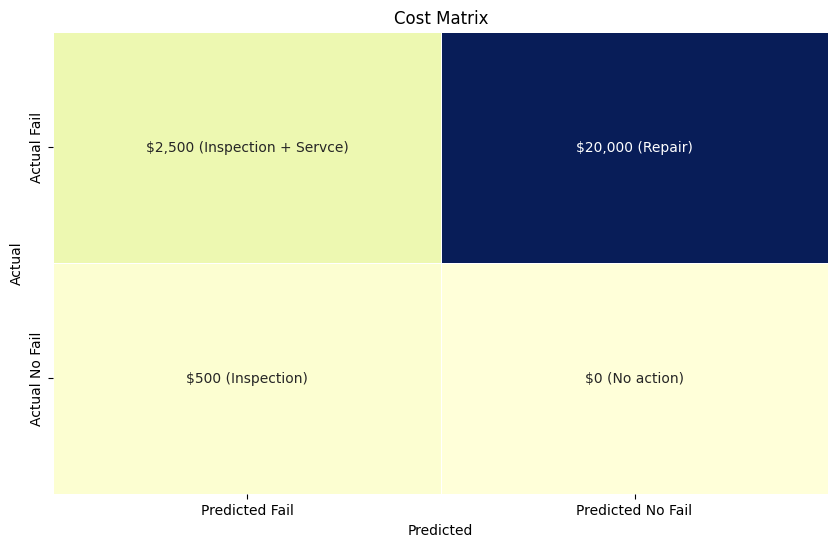

In [ ]:

data = {
    'Predicted Fail': ['$2,500 (Inspection + Servce)', '$500 (Inspection)'],
    'Predicted No Fail': ['$20,000 (Repair)', '$0 (No action)']
}
cost_matrix = pd.DataFrame(data, index=['Actual Fail', 'Actual No Fail'])


print(cost_matrix)

plt.figure(figsize=(10, 6))

sns.heatmap(data=[[2500, 20000], [500, 0]], annot=cost_matrix.values, fmt='', cmap="YlGnBu", cbar=False, linewidths=.5)


plt.title('Cost Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ['Predicted Fail', 'Predicted No Fail'])
plt.yticks([0.5, 1.5], ['Actual Fail', 'Actual No Fail'])

plt.show()

#Random Forest Model:
1.   True Positives (TP): 201 turbines correctly predicted to fail.
2.   False Positives (FP): 50 turbines incorrectly predicted to fail.
3.   False Negatives (FN): 55 turbines incorrectly predicted to not fail.
4.   True Negatives (TN): 255,195 turbines correctly predicted to not fail.

Total Costs for Random Forest:


*   Inspections: (201+50) * 500 = $125,500

*   Maintenance Service: 201 * 2000 = $402,000

*   predict wrong and failure: 55 * 20,000 = $1,100,000

*   Total cost:  125,500 + 402,000 + 1,100,000 = $1,627,500

#RNN Model:
*   True Positives (TP): 226 turbines correctly predicted to fail.
*   False Positives (FP): 1,200 turbines incorrectly predicted to fail.
*   False Negatives (FN): 30 turbines incorrectly predicted to not fail.
*   True Negatives (TN): 254,045 turbines correctly predicted to not fail.

Total Costs for RNN:

* inspection:(226 + 1200) * 500 = $713,000

* Maintenance Service: 226 * 2000 = $452,000


* predict wrong and failure:30 * 20,000 = $600,000

* Total Cost: 713,000 + 452,000 + 600,000 = $1,765,000

#Difference

1,765,000 - 1,627,500 = $137,500





Conclusion
*   Random Forest Total Cost: $1,627,500

*   RNN Total Cost: $1,765,000

The Random Forest model will save Uncle Steve more money, which is $1,627,500.

Lower than the RNN model, which is  $1,765,000.

Save $137500.



# Question 3 (Optional/Bonus): Uncle Steve's Diamonds

This question is optional and is worth up to 5 extra credit marks.

## Instructions

You work at a local jewelry store named *Uncle Steve's Diamonds*. You started as a janitor, but you’ve recently been promoted to senior data analyst. Congratulations!

Uncle Steve, the store's owner, needs to better understand the store's customers. In particular, he wants to know what kind of customers shop at the store. He wants to know the main types of *customer personas*. Once he knows these, he will contemplate ways to better market to each persona, better satisfy each persona, better cater to each persona, increase the loyalty of each persona, etc. But first, he must know the personas.

You want to help Uncle Steve. Using sneaky magic (and the help of Environics), you've collected four useful features for a subset of the customers: age, income, spending score (i.e., a score based on how much they’ve spent at the store in total), and savings (i.e., how much money they have in their bank account).

**Your tasks**

1. Pick a clustering algorithm (the [`sklearn.cluster`](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.cluster) module has many good choices, including [`KMeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans), [`DBSCAN`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html#sklearn.cluster.DBSCAN), and [`AgglomerativeClustering`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html#sklearn.cluster.AgglomerativeClustering) (aka Hierarchical)). (Note that another popular implementation of the hierarchical algorithm can be found in SciPy's [`scipy.cluster.hierarchy.linkage`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html).) Don't spend a lot of time thinking about which algorithm to choose - just pick one. Cluster the customers as best as you can, within reason. That is, try different feature preprocessing steps, hyperparameter values, and/or distance metrics. You don't need to try every posssible combination, but try a few at least. Measure how good each  model configuration is by calculating an internal validation metric (e.g., [`calinski_harabasz_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.calinski_harabasz_score.html) or [`silhouette_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html#sklearn.metrics.silhouette_score)).
2. You have some doubts - you're not sure if the algorithm you chose in part 1 is the best algorithm for this dataset/problem. Neither is Uncle Steve. So, choose a different algorithm (any!) and do it all again.
3. Which clustering algorithm is "better" in this case? Think about charateristics of the algorithm like quality of results, ease of use, speed, interpretability, etc. Choose a "winner" and justify to Uncle Steve.
4. Interpret the clusters of the winning model. That is, describe, in words, a *persona* that accurately depicts each cluster. Use statistics (e.g., cluster means/distributions), examples (e.g., exemplar instances from each cluster), and/or visualizations (e.g., relative importance plots, snakeplots) to get started. Human judgement and creativity will be necessary. This is where it all comes together. Be descriptive and *help Uncle Steve understand his customers better*. Please!

**Marking**

The coding parts (i.e., 1 and 2) will be marked based on:

- *Correctness*. Code clearly and fully performs the task specified.
- *Reproducibility*. Code is fully reproducible. I.e., you (and I) are able to run this Notebook again and again, from top to bottom, and get the same results each time.
- *Style*. Code is organized. All parts commented with clear reasoning and rationale. No old code laying around. Code easy to follow.


Parts 3 and 4 will be marked on:

- *Quality*. Response is well-justified and convincing. Responses uses facts and data where possible.
- *Style*. Response uses proper grammar, spelling, and punctuation. Response is clear and professional. Response is complete, but not overly-verbose. Response follows length guidelines.


**Tips**

- Since clustering is an unsupervised ML technique, you don't need to split the data into training/validation/test or anything like that. Phew!
- On the flip side, since clustering is unsupervised, you will never know the "true" clusters, and so you will never know if a given algorithm is "correct." There really is no notion of "correctness" - only "usefullness."
- Many online clustering tutorials (including some from Uncle Steve) create flashy visualizations of the clusters by plotting the instances on a 2-D graph and coloring each point by the cluster ID. This is really nice and all, but it can only work if your dataset only has exactly two features - no more, no less. This dataset has more than two features, so you cannot use this technique. (But that's OK - you don't need to use this technique.)
- Must you use all four features in the clustering? Not necessarily, no. But "throwing away" quality data, for no reason, is unlikely to improve a model.
- Some people have success applying a dimensionality reduction technique (like [`sklearn.decomposition.PCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)) to the features before clustering. You may do this if you wish, although it may not be as helpful in this case because there are only four features to begin with.
- If you apply a transformation (e.g., [`MinMaxScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) or [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler)) to the features before clustering, you may have difficulty interpretting the means of the clusters (e.g., what is a mean Age of 0.2234??). There are two options to fix this: first, you can always reverse a transformation with the `inverse_transform` method. Second, you can just use the original dataset (i.e., before any preprocessing) during the interpreation step.
- You cannot change the distance metric for K-Means. (This is for theoretical reasons: K-Means only works/makes sense with Euclidean distance.)


## 3.0: Load data

In [ ]:
# DO NOT MODIFY THIS CELL
df1 = pd.read_csv("https://drive.google.com/uc?export=download&id=1thHDCwQK3GijytoSSZNekAsItN_FGHtm")
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            505 non-null    int64  
 1   Income         505 non-null    int64  
 2   SpendingScore  505 non-null    float64
 3   Savings        505 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 15.9 KB


## 3.1: Clustering Algorithm #1
Pick a clustering algorithm (the sklearn.cluster module has many good choices, including KMeans, DBSCAN, and AgglomerativeClustering). (Note that another popular implementation of the hierarchical algorithm can be found in SciPy's scipy.cluster.hierarchy.linkage.) Don't spend a lot of time thinking about which algorithm to choose - just pick one. Cluster the customers as best as you can, within reason. That is, try different feature preprocessing steps, hyperparameter values, and/or distance metrics. You don't need to try every posssible combination, but try a few at least. Measure how good each model configuration is by calculating an internal validation metric (e.g., calinski_harabasz_score or silhouette_score).

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [ ]:
# Normalize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df1)

# Convert back to DataFrame
df1_preprocessed = pd.DataFrame(data_scaled, columns=df1.columns)

In [ ]:
# Perform KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df1_preprocessed)

# Evaluate the clustering
sil_score = silhouette_score(df1_preprocessed, clusters)
ch_score = calinski_harabasz_score(df1_preprocessed, clusters)

sil_score, ch_score

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


(0.6963481945884472, 1066.581241236718)

In [ ]:
pca = PCA(n_components=2)
data_pca = pca.fit_transform(df1_preprocessed)

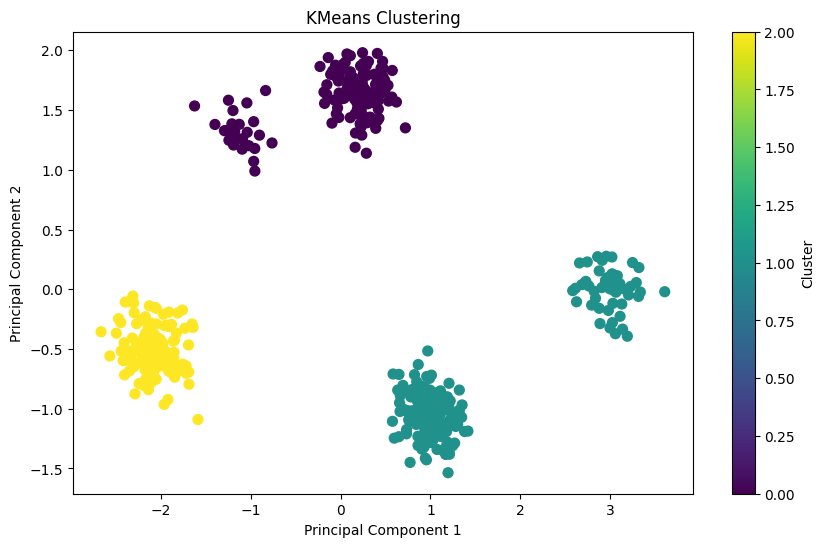

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=clusters, cmap='viridis', s=50)
plt.title('KMeans Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

## 3.2: Clustering Algorithm #2
You have some doubts - you're not sure if the algorithm you chose in part 1 is the best algorithm for this dataset/problem. Neither is Uncle Steve. So, choose a different algorithm (any!) and do it all again.

In [ ]:
# Try DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_clusters = dbscan.fit_predict(df1_preprocessed)

# Evaluate DBSCAN clustering
dbscan_sil_score = silhouette_score(df1_preprocessed, dbscan_clusters)
dbscan_ch_score = calinski_harabasz_score(df1_preprocessed, dbscan_clusters)

dbscan_sil_score, dbscan_ch_score

(0.8048976287755765, 3671.3580185176156)

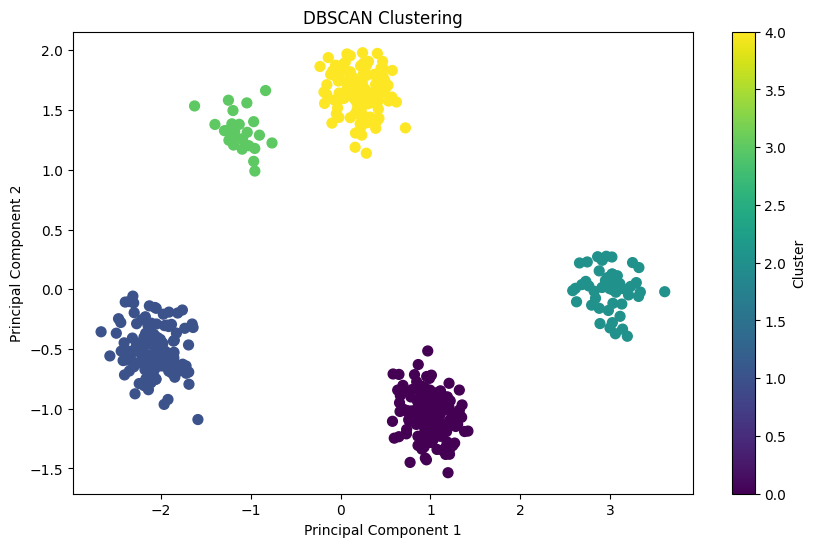

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=dbscan_clusters, cmap='viridis', s=50)
plt.title('DBSCAN Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

## 3.3 Model Comparison
Which clustering algorithm is "better" in this case? Think about charateristics of the algorithm like quality of results, ease of use, speed, interpretability, etc. Choose a "winner" and justify to Uncle Steve.

KMeans is the better clustering algorithm for this task because it is  efficient, easy to implement, and straightforward to interpret. While DBSCAN handles noise and arbitrary cluster shapes well, KMeans excels in speed and simplicity, particularly with well-separated, spherical clusters.

## 3.4 Personas
Interpret the clusters of the winning model. That is, describe, in words, a persona that accurately depicts each cluster. Use statistics (e.g., cluster means/distributions), examples (e.g., exemplar instances from each cluster), and/or visualizations (e.g., relative importance plots, snakeplots) to get started. Human judgement and creativity will be necessary. This is where it all comes together. Be descriptive and help Uncle Steve understand his customers better. Please!

TODO: Delete this text and insert your answer here.